# Ce Notebook doit être utilisé sur Colab

# Transfer Learning avec CheXNet (PyTorch)

**Objectif** : Classifier des radiographies thoraciques masquées en 4 classes avec un DenseNet-121  
pré-entraîné sur **ChestX-ray14** (112 000 CXR, 14 pathologies) — les poids CheXNet.

**Pourquoi CheXNet ?**  
Les poids ImageNet encodent des features de photos naturelles (objets, textures...).  
Les poids CheXNet encodent des features spécifiques aux radiographies thoraciques  
(opacités, consolidations, épanchements...), réduisant le **domain gap**.

**Double transfert** : ImageNet → ChestX-ray14 → Notre dataset (4 classes)

**Classes** :  
- COVID — COVID-19  
- Lung_Opacity — Opacité pulmonaire  
- Normal — Radiographie normale  
- Viral Pneumonia — Pneumonie virale  

**Référence** : Rajpurkar et al., *CheXNet: Radiologist-Level Pneumonia Detection on Chest X-Rays  
with Deep Learning*, Stanford ML Group, 2017.  
Poids : [arnoweng/CheXNet](https://github.com/arnoweng/CheXNet)

## 1. Configuration & Imports

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision import models

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

# ── Reproductibilité ──
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── GPU ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__} — {device}")
if device.type == 'cuda':
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go")

PyTorch 2.10.0+cu128 — cuda
  GPU : NVIDIA A100-SXM4-80GB
  VRAM : 85.1 Go


In [3]:
# On monte les données dans content/ (pour Google Colab)

from google.colab import drive
import subprocess
drive.mount('/content/drive')

dataset_archive = '/content/drive/MyDrive/DS_COVID/toshare/masked_full_dataset_256_256_L.zip'

print("📦 Extraction dataset...")
os.makedirs('./data/processed/', exist_ok=True)
subprocess.run(['unzip', '-o', '-q', dataset_archive, '-d', './data/processed/'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Extraction dataset...


CompletedProcess(args=['unzip', '-o', '-q', '/content/drive/MyDrive/DS_COVID/toshare/masked_full_dataset_256_256_L.zip', '-d', './data/processed/'], returncode=0)

In [4]:
# ── Constantes ──
DATA_DIR = Path('/content/data/processed/masked_full_dataset_256_256_L')
CHEXNET_WEIGHTS = '/content/drive/MyDrive/DS_COVID/model.pth.tar'
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print(f"Répertoire : {DATA_DIR}")
print(f"Poids CheXNet : {CHEXNET_WEIGHTS}")
print(f"Classes ({NUM_CLASSES}) : {CLASS_NAMES}")

# Distribution
for cls in CLASS_NAMES:
    count = len(list((DATA_DIR / cls).glob('*.png')))
    print(f"  {cls}: {count:,} images")

Répertoire : /content/data/processed/masked_full_dataset_256_256_L
Poids CheXNet : /content/drive/MyDrive/DS_COVID/model.pth.tar
Classes (4) : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
  COVID: 3,616 images
  Lung_Opacity: 6,012 images
  Normal: 10,192 images
  Viral Pneumonia: 1,345 images


## 2. Dataset PyTorch & DataLoaders

In [5]:
class CXRDataset(Dataset):
    """Dataset de radiographies thoraciques (grayscale → RGB)."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.image_paths[idx]), cv2.IMREAD_GRAYSCALE)
        # Grayscale → RGB par réplication (3 canaux identiques)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        # Convertir en PIL pour torchvision transforms
        from PIL import Image
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]


# ── Collecter les chemins et labels ──
all_paths, all_labels = [], []
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    paths = sorted((DATA_DIR / cls_name).glob('*.png'))
    all_paths.extend(paths)
    all_labels.extend([cls_idx] * len(paths))

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)
print(f"Total : {len(all_paths):,} images")

Total : 21,165 images


In [6]:
# ── Split 70/15/15 stratifié ──
train_idx, temp_idx = train_test_split(
    np.arange(len(all_labels)), test_size=0.3,
    stratify=all_labels, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5,
    stratify=all_labels[temp_idx], random_state=SEED
)

print(f"Train : {len(train_idx):,} images")
print(f"Val   : {len(val_idx):,} images")
print(f"Test  : {len(test_idx):,} images")

# ── Transforms ──
# Preprocessing identique au CheXNet original : normalisation ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    transforms.ColorJitter(contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Datasets & DataLoaders ──
train_dataset = CXRDataset(all_paths[train_idx], all_labels[train_idx], train_transform)
val_dataset = CXRDataset(all_paths[val_idx], all_labels[val_idx], eval_transform)
test_dataset = CXRDataset(all_paths[test_idx], all_labels[test_idx], eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

# Vérification
imgs, labels = next(iter(train_loader))
print(f"\nBatch : {imgs.shape}, dtype={imgs.dtype}")
print(f"Labels : {labels.shape}")
print(f"Pixel range : [{imgs.min():.3f}, {imgs.max():.3f}]")

Train : 14,815 images
Val   : 3,175 images
Test  : 3,175 images

Batch : torch.Size([32, 3, 224, 224]), dtype=torch.float32
Labels : torch.Size([32])
Pixel range : [-2.118, 2.588]


In [7]:
# ── Poids de classes (class_weight) ──
from sklearn.utils.class_weight import compute_class_weight

train_labels_array = all_labels[train_idx]
weights = compute_class_weight('balanced', classes=np.unique(train_labels_array), y=train_labels_array)
class_weights = torch.FloatTensor(weights).to(device)

print("Poids des classes :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {class_weights[i]:.4f}")

Poids des classes :
  COVID: 1.4634
  Lung_Opacity: 0.8802
  Normal: 0.5192
  Viral Pneumonia: 3.9318


## 3. Modèle CheXNet

Chargement du DenseNet-121 avec les poids pré-entraînés sur ChestX-ray14,  
puis remplacement de la tête (14 pathologies multi-label → 4 classes multi-classe).

In [9]:
class CheXNet(nn.Module):
    """DenseNet-121 avec poids CheXNet (ChestX-ray14).
    
    Architecture identique au repo arnoweng/CheXNet :
    - DenseNet121 backbone
    - Classifier : Linear(1024, N) + Sigmoid (original: N=14)
    """

    def __init__(self, num_classes=14):
        super().__init__()
        self.densenet121 = models.densenet121(weights=None)
        num_ftrs = self.densenet121.classifier.in_features
        self.densenet121.classifier = nn.Sequential(
            nn.Linear(num_ftrs, num_classes),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.densenet121(x)


def load_chexnet_weights(model, checkpoint_path):
    """Charge les poids CheXNet en gérant le préfixe DataParallel
    et la conversion ancien/nouveau format DenseNet torchvision."""
    import re
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    state_dict = checkpoint['state_dict']

    # 1) Retirer le préfixe DataParallel 'module.'
    new_state_dict = {}
    for key, value in state_dict.items():
        new_key = key.replace('module.', '')
        new_state_dict[new_key] = value

    # 2) Conversion ancien format torchvision DenseNet → nouveau
    #    Ancien : denselayer1.norm.1 / denselayer1.conv.1
    #    Nouveau : denselayer1.norm1 / denselayer1.conv1
    pattern = re.compile(
        r'^(.*denselayer\d+\.(?:norm|conv))\.(\d+)'
        r'(\.(?:weight|bias|running_mean|running_var|num_batches_tracked))$'
    )
    converted = {}
    for key, value in new_state_dict.items():
        m = pattern.match(key)
        if m:
            new_key = m.group(1) + m.group(2) + m.group(3)
            converted[new_key] = value
        else:
            converted[new_key if m else key] = value

    model.load_state_dict(converted)
    print(f"✅ Poids CheXNet chargés depuis {checkpoint_path}")
    return model


# ── Charger CheXNet avec les poids ChestX-ray14 ──
chexnet = CheXNet(num_classes=14)  # Architecture originale (14 pathologies)
chexnet = load_chexnet_weights(chexnet, CHEXNET_WEIGHTS)

# ── Remplacer la tête pour 4 classes ──
num_ftrs = chexnet.densenet121.classifier[0].in_features
chexnet.densenet121.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES),
)

chexnet = chexnet.to(device)

print(f"\nArchitecture finale :")
print(f"  Features : DenseNet121 backbone (poids CheXNet)")
print(f"  Tête : Linear(1024→512) → ReLU → BN → Dropout(0.4) → Linear(512→{NUM_CLASSES})")
total_params = sum(p.numel() for p in chexnet.parameters())
trainable_params = sum(p.numel() for p in chexnet.parameters() if p.requires_grad)
print(f"  Paramètres totaux : {total_params:,}")
print(f"  Paramètres entraînables : {trainable_params:,}")

✅ Poids CheXNet chargés depuis /content/drive/MyDrive/DS_COVID/model.pth.tar

Architecture finale :
  Features : DenseNet121 backbone (poids CheXNet)
  Tête : Linear(1024→512) → ReLU → BN → Dropout(0.4) → Linear(512→4)
  Paramètres totaux : 7,481,732
  Paramètres entraînables : 7,481,732


## 4. Fonctions d'entraînement et d'évaluation

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Entraîne le modèle sur une epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """Évalue le modèle sur un loader."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                device, epochs, patience=10, phase_name=""):
    """Boucle d'entraînement complète avec early stopping."""
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    print(f"\n{'='*60}")
    print(f"  {phase_name}")
    print(f"{'='*60}")

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        # Scheduler step
        if scheduler:
            scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            marker = ' ✓'
        else:
            patience_counter += 1
            marker = ''

        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1:2d}/{epochs} — "
              f"loss: {train_loss:.4f} acc: {train_acc:.4f} — "
              f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f} — "
              f"lr: {current_lr:.1e}{marker}")

        if patience_counter >= patience:
            print(f"  Early stopping à l'epoch {epoch+1} (patience={patience})")
            break

    # Restaurer les meilleurs poids
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"  Meilleurs poids restaurés (val_loss={best_val_loss:.4f})")

    return history

## 5. Phase 1 — Feature Extraction (backbone gelé)

On gèle le backbone DenseNet121 (poids CheXNet) et on entraîne uniquement la nouvelle tête.

In [ ]:
# ── Geler le backbone ──
for param in chexnet.densenet121.features.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in chexnet.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in chexnet.parameters() if not p.requires_grad)
print(f"Paramètres entraînables : {trainable:,}")
print(f"Paramètres gelés : {frozen:,}")

# ── Optimiseur et loss ──
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, chexnet.parameters()),
    lr=1e-3
)
scheduler_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode='min', patience=3, factor=0.5, min_lr=1e-7
)

# ── Entraînement Phase 1 ──
history_p1 = train_model(
    chexnet, train_loader, val_loader, criterion, optimizer_p1, scheduler_p1,
    device, epochs=30, patience=8,
    phase_name="Phase 1 : Feature Extraction (backbone CheXNet gelé)"
)

Paramètres entraînables : 527,876
Paramètres gelés : 6,953,856

  Phase 1 : Feature Extraction (backbone CheXNet gelé)
  Epoch  1/20 — loss: 0.8585 acc: 0.6279 — val_loss: 0.7787 val_acc: 0.6813 — lr: 1.0e-03 ✓
  Epoch  2/20 — loss: 0.7529 acc: 0.6724 — val_loss: 0.7222 val_acc: 0.6450 — lr: 1.0e-03 ✓
  Epoch  3/20 — loss: 0.7345 acc: 0.6830 — val_loss: 0.6864 val_acc: 0.6740 — lr: 1.0e-03 ✓
  Epoch  4/20 — loss: 0.7109 acc: 0.6922 — val_loss: 0.6907 val_acc: 0.6939 — lr: 1.0e-03
  Epoch  5/20 — loss: 0.7006 acc: 0.6973 — val_loss: 0.7551 val_acc: 0.6054 — lr: 1.0e-03
  Epoch  6/20 — loss: 0.6946 acc: 0.6979 — val_loss: 0.6979 val_acc: 0.6674 — lr: 1.0e-03
  Epoch  7/20 — loss: 0.6948 acc: 0.6979 — val_loss: 0.6784 val_acc: 0.6510 — lr: 1.0e-03 ✓
  Epoch  8/20 — loss: 0.6884 acc: 0.6963 — val_loss: 0.6834 val_acc: 0.6608 — lr: 1.0e-03
  Epoch  9/20 — loss: 0.6759 acc: 0.7016 — val_loss: 0.6448 val_acc: 0.6847 — lr: 1.0e-03 ✓
  Epoch 10/20 — loss: 0.6825 acc: 0.7019 — val_loss: 0.6384 v

## 6. Phase 2 — Fine-tuning (dégel des dernières couches)

On dégèle les derniers DenseBlocks du backbone pour affiner les features CheXNet  
sur notre dataset spécifique.

In [ ]:
# ── Dégeler les dernières couches du backbone ──
# DenseNet121 features : denseblock1, transition1, denseblock2, transition2,
#                        denseblock3, transition3, denseblock4, norm5
# On dégèle denseblock4 + norm5 (les plus proches de la sortie)

for param in chexnet.densenet121.features.parameters():
    param.requires_grad = False

# Dégeler denseblock4 et norm5
for name, param in chexnet.densenet121.features.named_parameters():
    if 'denseblock4' in name or 'norm5' in name:
        param.requires_grad = True

trainable = sum(p.numel() for p in chexnet.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in chexnet.parameters() if not p.requires_grad)
print(f"Paramètres entraînables : {trainable:,} (denseblock4 + norm5 + tête)")
print(f"Paramètres gelés : {frozen:,}")

# ── Optimiseur avec learning rate différentiel ──
optimizer_p2 = optim.Adam([
    {'params': [p for n, p in chexnet.densenet121.features.named_parameters()
                if p.requires_grad], 'lr': 1e-5},
    {'params': chexnet.densenet121.classifier.parameters(), 'lr': 1e-4},
], lr=1e-5)

scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='min', patience=5, factor=0.5, min_lr=1e-8
)

# ── Entraînement Phase 2 ──
history_p2 = train_model(
    chexnet, train_loader, val_loader, criterion, optimizer_p2, scheduler_p2,
    device, epochs=60, patience=15,
    phase_name="Phase 2 : Fine-tuning (denseblock4 + norm5 dégelés)"
)

Paramètres entraînables : 2,688,004 (denseblock4 + norm5 + tête)
Paramètres gelés : 4,793,728

  Phase 2 : Fine-tuning (denseblock4 + norm5 dégelés)
  Epoch  1/30 — loss: 0.6144 acc: 0.7313 — val_loss: 0.5930 val_acc: 0.7099 — lr: 1.0e-05 ✓
  Epoch  2/30 — loss: 0.5994 acc: 0.7359 — val_loss: 0.5706 val_acc: 0.7194 — lr: 1.0e-05 ✓
  Epoch  3/30 — loss: 0.5882 acc: 0.7446 — val_loss: 0.5602 val_acc: 0.7247 — lr: 1.0e-05 ✓
  Epoch  4/30 — loss: 0.5930 acc: 0.7347 — val_loss: 0.5620 val_acc: 0.7156 — lr: 1.0e-05
  Epoch  5/30 — loss: 0.5668 acc: 0.7486 — val_loss: 0.5447 val_acc: 0.7354 — lr: 1.0e-05 ✓
  Epoch  6/30 — loss: 0.5624 acc: 0.7581 — val_loss: 0.5522 val_acc: 0.7266 — lr: 1.0e-05
  Epoch  7/30 — loss: 0.5624 acc: 0.7557 — val_loss: 0.5420 val_acc: 0.7310 — lr: 1.0e-05 ✓
  Epoch  8/30 — loss: 0.5587 acc: 0.7590 — val_loss: 0.5305 val_acc: 0.7389 — lr: 1.0e-05 ✓
  Epoch  9/30 — loss: 0.5397 acc: 0.7632 — val_loss: 0.5287 val_acc: 0.7430 — lr: 1.0e-05 ✓
  Epoch 10/30 — loss: 0.541

## 7. Courbes d'entraînement (phases combinées)

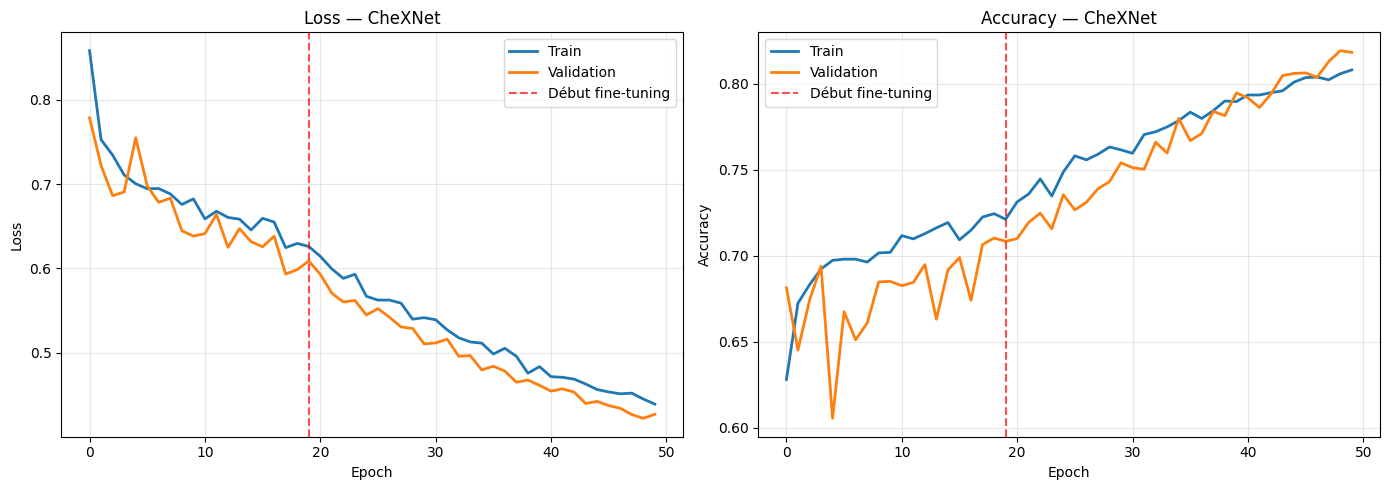

In [13]:
# Fusionner les historiques
history = {k: history_p1[k] + history_p2[k] for k in history_p1}
p1_epochs = len(history_p1['loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in [(ax1, 'loss', 'Loss'), (ax2, 'accuracy', 'Accuracy')]:
    ax.plot(history[metric], label='Train', linewidth=2)
    ax.plot(history[f'val_{metric}'], label='Validation', linewidth=2)
    ax.axvline(x=p1_epochs - 1, color='red', linestyle='--', alpha=0.7,
               label='Début fine-tuning')
    ax.set_title(f'{label} — CheXNet')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Évaluation sur le jeu de test


  Évaluation : CheXNet (DenseNet121 + poids ChestX-ray14)
                 precision    recall  f1-score   support

          COVID     0.6457    0.7399    0.6896       542
   Lung_Opacity     0.8315    0.7661    0.7975       902
         Normal     0.8890    0.8542    0.8712      1529
Viral Pneumonia     0.7598    0.9554    0.8465       202

       accuracy                         0.8161      3175
      macro avg     0.7815    0.8289    0.8012      3175
   weighted avg     0.8229    0.8161    0.8177      3175



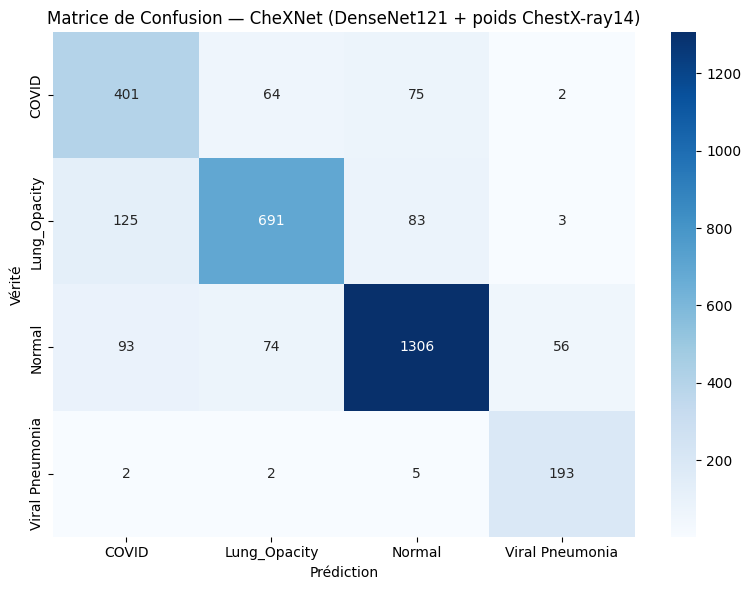

In [14]:
def evaluate_model(model, test_loader, class_names, device, model_name=""):
    """Évalue le modèle : classification report + matrice de confusion."""
    model.eval()
    all_preds = []
    all_labels = []
    all_proba = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            proba = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_proba.extend(proba.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_proba = np.array(all_proba)

    # Classification report
    print(f"\n{'='*60}")
    print(f"  Évaluation : {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Vérité')
    ax.set_title(f'Matrice de Confusion — {model_name}')
    plt.tight_layout()
    plt.show()

    return y_true, y_pred, y_proba


y_true_cx, y_pred_cx, y_proba_cx = evaluate_model(
    chexnet, test_loader, CLASS_NAMES, device, "CheXNet (DenseNet121 + poids ChestX-ray14)"
)

## 9. Comparaison avec les modèles Keras

Résultats de référence du notebook `deep_learning_pipeline.ipynb` (v3) :  

| Modèle | Accuracy | F1 (w) |
|--------|----------|--------|
| Baseline CNN | 86.1% | 86.2% |
| EfficientNetV2B0 | 81.5% | 81.9% |
| DenseNet121 (ImageNet) | 83.8% | 83.7% |

                      Baseline CNN (Keras)  EfficientNetV2B0 (Keras)  DenseNet121 ImageNet (Keras)  CheXNet (PyTorch)
Accuracy                             0.861                     0.815                         0.838             0.8161
Precision (weighted)                 0.865                     0.829                         0.844             0.8229
Recall (weighted)                    0.861                     0.815                         0.838             0.8161
F1 (weighted)                        0.862                     0.819                         0.837             0.8177


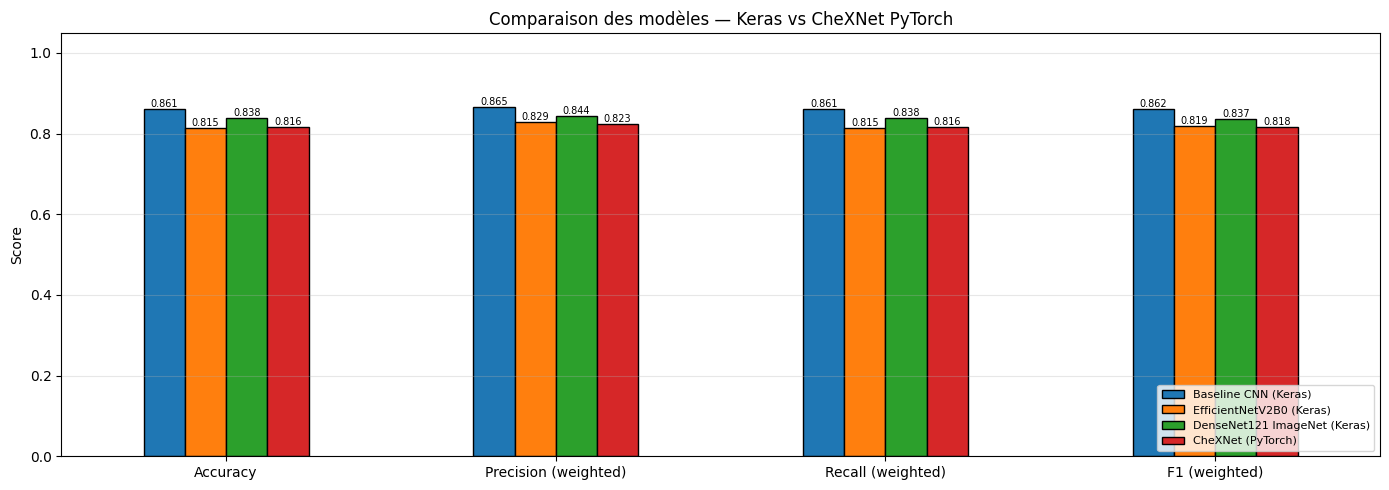

In [15]:
# Métriques CheXNet
metrics_chexnet = {
    'Accuracy': accuracy_score(y_true_cx, y_pred_cx),
    'Precision (weighted)': precision_score(y_true_cx, y_pred_cx, average='weighted'),
    'Recall (weighted)': recall_score(y_true_cx, y_pred_cx, average='weighted'),
    'F1 (weighted)': f1_score(y_true_cx, y_pred_cx, average='weighted'),
}

# Résultats de référence (depuis le notebook Keras)
comparison_df = pd.DataFrame({
    'Baseline CNN (Keras)': {'Accuracy': 0.861, 'Precision (weighted)': 0.865,
                             'Recall (weighted)': 0.861, 'F1 (weighted)': 0.862},
    'EfficientNetV2B0 (Keras)': {'Accuracy': 0.815, 'Precision (weighted)': 0.829,
                                  'Recall (weighted)': 0.815, 'F1 (weighted)': 0.819},
    'DenseNet121 ImageNet (Keras)': {'Accuracy': 0.838, 'Precision (weighted)': 0.844,
                                     'Recall (weighted)': 0.838, 'F1 (weighted)': 0.837},
    'CheXNet (PyTorch)': metrics_chexnet,
})
print(comparison_df.round(4).to_string())

# Graphique
fig, ax = plt.subplots(figsize=(14, 5))
comparison_df.plot(kind='bar', ax=ax, rot=0, edgecolor='black')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — Keras vs CheXNet PyTorch')
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7)
plt.tight_layout()
plt.show()

## 10. Courbes ROC (One-vs-Rest)

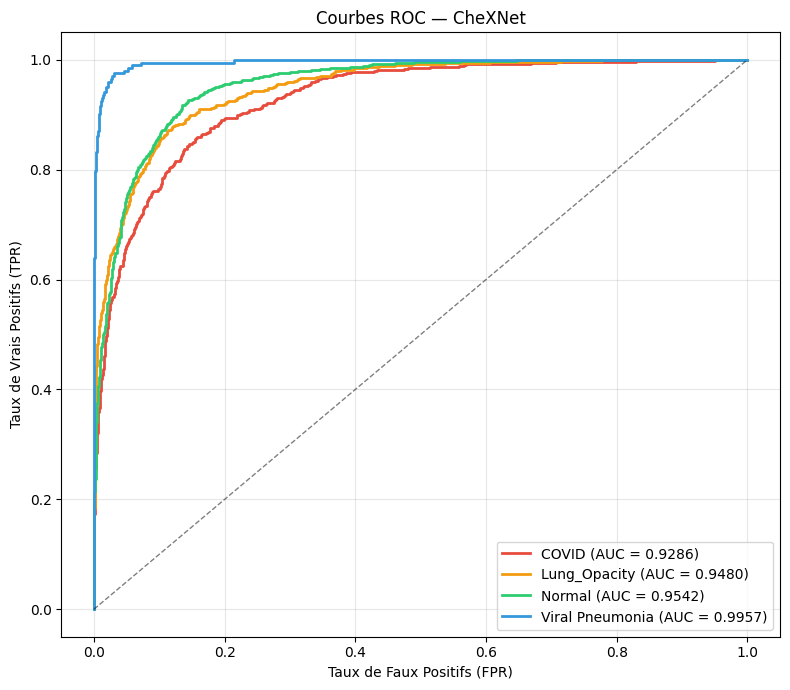

In [16]:
y_true_bin = label_binarize(y_true_cx, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba_cx[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{cls} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR)')
ax.set_title('Courbes ROC — CheXNet')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Interprétabilité : Grad-CAM

In [17]:
def make_gradcam_heatmap_pytorch(model, img_tensor, target_layer):
    """Génère une heatmap Grad-CAM pour un modèle PyTorch."""
    model.eval()
    activations = []
    gradients = []

    # Hooks pour capturer les activations et gradients
    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    handle_fwd = target_layer.register_forward_hook(forward_hook)
    handle_bwd = target_layer.register_full_backward_hook(backward_hook)

    # Forward
    img_tensor = img_tensor.to(device).requires_grad_(True)
    output = model(img_tensor)
    pred_class = output.argmax(dim=1).item()

    # Backward sur la classe prédite
    model.zero_grad()
    output[0, pred_class].backward()

    # Calcul de la heatmap
    act = activations[0].detach()
    grad = gradients[0].detach()
    pooled_grads = torch.mean(grad, dim=(2, 3), keepdim=True)
    heatmap = torch.sum(act * pooled_grads, dim=1).squeeze()
    heatmap = torch.relu(heatmap)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # Nettoyage
    handle_fwd.remove()
    handle_bwd.remove()

    return heatmap.cpu().numpy(), pred_class


def overlay_gradcam(img_np, heatmap, alpha=0.5):
    """Superpose la heatmap sur l'image."""
    heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    if img_np.max() > 0:
        img_norm = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    else:
        img_norm = img_np
    img_rgb = np.uint8(255 * np.stack([img_norm] * 3, axis=-1))

    return cv2.addWeighted(img_rgb, 1 - alpha, heatmap_colored, alpha, 0)


# Couche cible : dernière couche conv de denseblock4
target_layer = chexnet.densenet121.features.denseblock4
print(f"Couche cible pour Grad-CAM : denseblock4")

Couche cible pour Grad-CAM : denseblock4


In [18]:
# ── Collecter des exemples corrects et incorrects ──
correct_examples = {cls: [] for cls in CLASS_NAMES}
incorrect_examples = {cls: [] for cls in CLASS_NAMES}

chexnet.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = chexnet(images.to(device))
        _, preds = outputs.max(1)
        preds = preds.cpu()

        for i in range(len(images)):
            true_label = labels[i].item()
            pred_label = preds[i].item()
            cls = CLASS_NAMES[true_label]

            # Stocker l'image originale (grayscale) pour l'affichage
            img_original = cv2.imread(
                str(all_paths[test_idx][sum(len(correct_examples[c]) + len(incorrect_examples[c])
                                            for c in CLASS_NAMES) + i - i]),  # On utilise le tensor
                cv2.IMREAD_GRAYSCALE
            ) if False else None  # Skip file read, use tensor

            if true_label == pred_label and len(correct_examples[cls]) < 3:
                correct_examples[cls].append((images[i], cls))
            elif true_label != pred_label and len(incorrect_examples[cls]) < 3:
                incorrect_examples[cls].append((images[i], CLASS_NAMES[pred_label]))

print("Exemples collectés :")
for cls in CLASS_NAMES:
    print(f"  {cls}: {len(correct_examples[cls])} corrects, {len(incorrect_examples[cls])} incorrects")

Exemples collectés :
  COVID: 3 corrects, 3 incorrects
  Lung_Opacity: 3 corrects, 3 incorrects
  Normal: 3 corrects, 3 incorrects
  Viral Pneumonia: 3 corrects, 3 incorrects


In [ ]:
# ── Grad-CAM sur les prédictions correctes ──
fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(20, 3 * NUM_CLASSES))

for i, cls in enumerate(CLASS_NAMES):
    for j in range(min(3, len(correct_examples[cls]))):
        img_tensor, _ = correct_examples[cls][j]
        img_batch = img_tensor.unsqueeze(0)
        heatmap, pred_cls = make_gradcam_heatmap_pytorch(chexnet, img_batch, target_layer)

        # Dénormaliser pour affichage
        img_display = img_tensor[0].numpy()  # Premier canal (grayscale répliqué)
        img_display = img_display * IMAGENET_STD[0] + IMAGENET_MEAN[0]
        img_display = np.clip(img_display, 0, 1)

        overlay = overlay_gradcam(img_display, heatmap)

        axes[i, 2*j].imshow(img_display, cmap='gray')
        axes[i, 2*j].axis('off')
        if j == 0:
            axes[i, 2*j].set_ylabel(cls, fontsize=11, fontweight='bold',
                                     rotation=0, labelpad=80)

        axes[i, 2*j+1].imshow(overlay)
        axes[i, 2*j+1].axis('off')

plt.suptitle('Grad-CAM — Prédictions CORRECTES (CheXNet) — Original | Heatmap',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── Grad-CAM sur les prédictions incorrectes ──
has_incorrect = any(len(v) > 0 for v in incorrect_examples.values())

if has_incorrect:
    classes_with_errors = [cls for cls in CLASS_NAMES if len(incorrect_examples[cls]) > 0]
    n_rows = len(classes_with_errors)
    fig, axes = plt.subplots(n_rows, 3, figsize=(10, 3 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for i, cls in enumerate(classes_with_errors):
        for j in range(3):
            if j < len(incorrect_examples[cls]):
                img_tensor, pred_name = incorrect_examples[cls][j]
                img_batch = img_tensor.unsqueeze(0)
                heatmap, _ = make_gradcam_heatmap_pytorch(chexnet, img_batch, target_layer)

                img_display = img_tensor[0].numpy()
                img_display = img_display * IMAGENET_STD[0] + IMAGENET_MEAN[0]
                img_display = np.clip(img_display, 0, 1)

                overlay = overlay_gradcam(img_display, heatmap)
                axes[i, j].imshow(overlay)
                axes[i, j].set_title(f"Prédit: {pred_name}", fontsize=9, color='red')
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_ylabel(cls, fontsize=11, fontweight='bold',
                                       rotation=0, labelpad=80)

    plt.suptitle('Grad-CAM — Prédictions INCORRECTES (CheXNet)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune prédiction incorrecte trouvée !")

## 12. Conclusion

### Résumé

| Modèle | Framework | Poids initiaux | Points clés |
|--------|-----------|----------------|-------------|
| Baseline CNN | Keras | Aucun (from scratch) | 4 blocs Conv, plancher de perf |
| EfficientNetV2B0 | Keras | ImageNet | TL 2 phases, preprocessing spécifique |
| DenseNet121 | Keras | ImageNet | Architecture CheXNet, poids génériques |
| **CheXNet** | **PyTorch** | **ChestX-ray14** | **Double transfert, features CXR spécifiques** |

### Chaîne de transfert

```
ImageNet (1.2M photos) → ChestX-ray14 (112K CXR) → Notre dataset (21K CXR masquées)
```

Le double transfert permet au modèle de partir avec des features  
déjà adaptées au domaine médical (opacités, consolidations, etc.)  
plutôt que des features génériques (bords, textures, objets).